In [1]:
import tensorflow as tf 

gpus = tf.config.list_physical_devices("GPU")

print(gpus)

2025-01-27 12:41:24.738648: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-27 12:41:24.764813: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-27 12:41:24.764833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-27 12:41:24.765657: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-27 12:41:24.770523: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import sys
sys.path.append('../tools_')

from tools import *

In [3]:
data_short_dir = "/home/alumnos/mburgosc/tfg/egm_reconstruction/Data_short"
egms_all_models = load_egms_df(data_short_dir)

data ['Simulation_01_210209_001_002', 'LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_201223_001_002', 'Simulation_01_190619_001_004', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'RA_RAA_141230', 'Simulation_01_200316_001_  1', 'TwoRotors_181219', 'RA_RAFW_SAF_140730', 'Simulation_01_200212_001_  4']


In [4]:
print(egms_all_models)

                              id  \
0   Simulation_01_210209_001_002   
1             LA_RSPV_CAF_150115   
2   Simulation_01_200428_001_001   
3   Simulation_01_201223_001_002   
4   Simulation_01_190619_001_004   
5   Simulation_01_190502_001_004   
6                 RA_RAFW_140807   
7                  RA_RAA_141230   
8   Simulation_01_200316_001_  1   
9               TwoRotors_181219   
10            RA_RAFW_SAF_140730   
11  Simulation_01_200212_001_  4   

                                            AF_signal  
0   [[9.479828179102282e-14, 0.04080228461795585, ...  
1   [[7.387776530722087, 9.094867906767199, 10.800...  
2   [[0.8807414426522221, 1.015404814148348, 0.963...  
3   [[4.24492593645743, 4.6424979299912765, 5.0315...  
4   [[-50.648764509652416, -48.25332554580271, -44...  
5   [[-61.093924858397685, -56.059614688222744, -5...  
6   [[-15.990956008585043, -14.190372868776846, -1...  
7   [[-1.5399639907851848, -1.421404688195314, -1....  
8   [[2.593443248791235, 2.

In [5]:
egms_values = egms_all_models["AF_signal"].tolist()
print(egms_values[0].shape)
print(len(egms_values))

(2048, 1500)
12


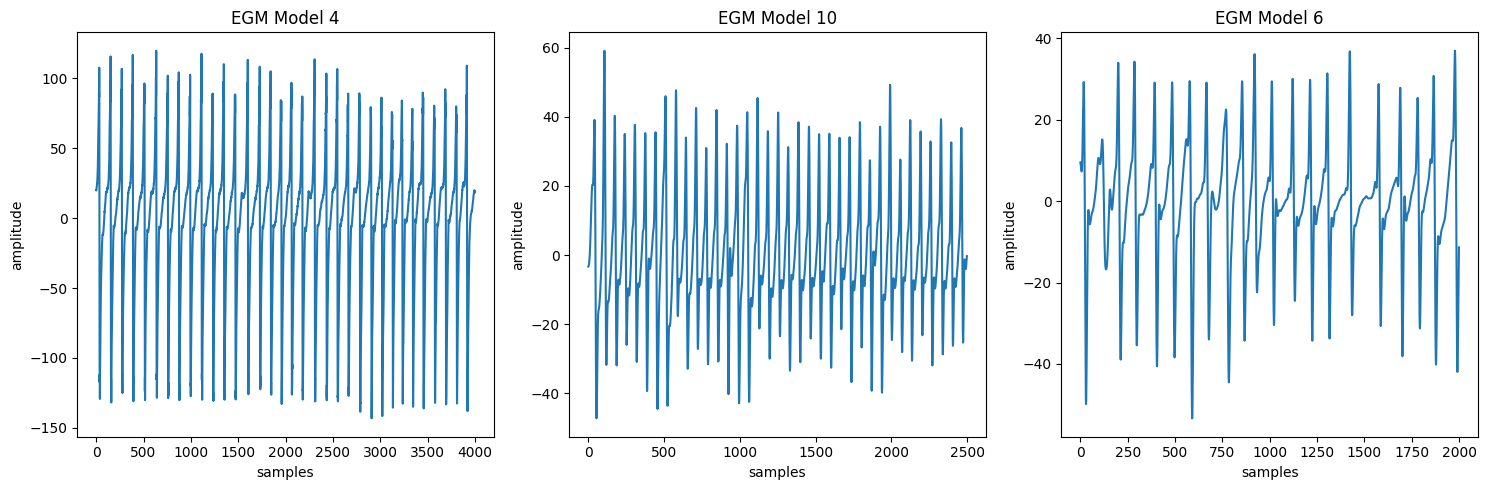

In [6]:
#plotting egms

import random

random_indices = random.sample(range(len(egms_values)), 3)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(random_indices):
    axs[i].plot(egms_values[idx][10, :]) 
    axs[i].set_title(f'EGM Model {idx}')  
    axs[i].set_xlabel('samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()


In [7]:

from tools import ECG_filtering

egms_filtered_norm = []

for i in range(len(egms_values)):
    
    #ECG FILTERING
    egms = egms_values[i]
    print(egms.shape)
    egms_filt = ECG_filtering(egms.T, 500)
    


    #NORMLIZE EGMS
    high = 1
    low = -1

    mins = np.min(egms_filt, axis=0)
    maxs = np.max(egms_filt, axis=0)
    rng = maxs - mins

    norm_egms = high - (((high - low) * (maxs - egms_filt)) / rng)
    
    norm_egms = norm_egms.T #para que queden otra vez (2048 x samples of time)
    egms_filtered_norm.append(norm_egms)



(2048, 1500)
(2048, 2499)
(2048, 1301)
(2048, 1500)
(2048, 4000)
(2048, 4000)
(2048, 2000)
(2048, 2000)
(2048, 2001)
(2048, 2499)
(2048, 2499)
(2048, 4501)


In [8]:
print(len(egms_filtered_norm))
print(egms_filtered_norm[0].shape)

#PREGUNTAR A OSCAR SI DEBERÍA ACOTAR TODOS A UN TIEMPO, POR EJEMPLO 1000 UNIDADES DE TIEMPO --> si hago esto puedo convertirlos en np arrays


12
(2048, 1500)


In [9]:
print(egms_filtered_norm[0][0, :].shape)

(1500,)


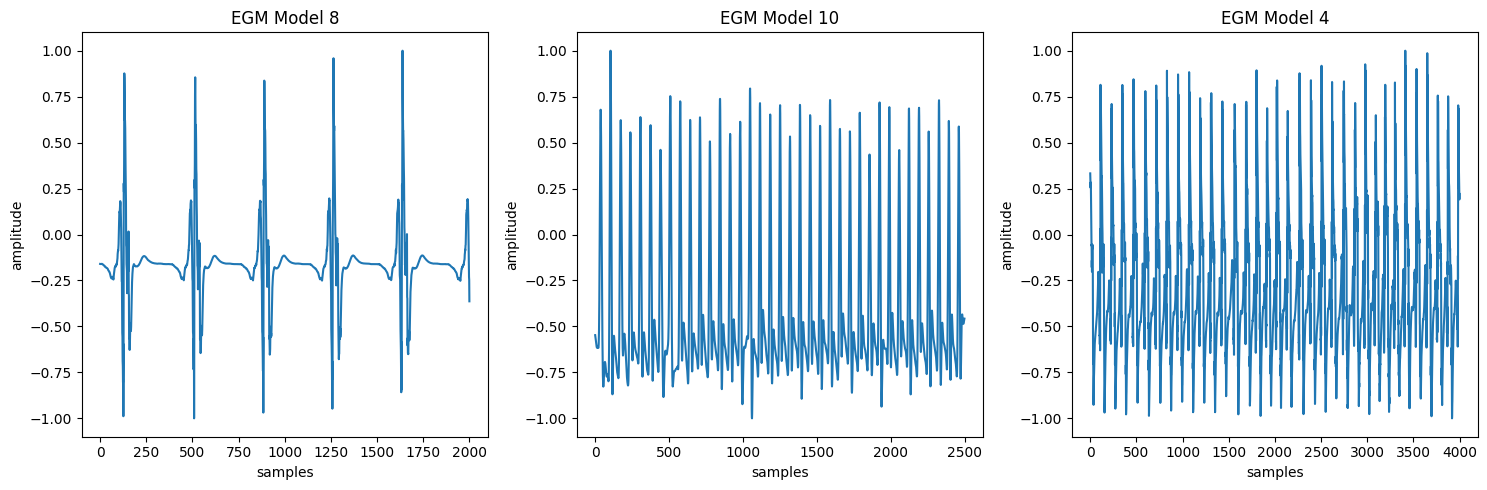

In [10]:
#plotting egms filtered and normalized

random_ind = random.sample(range(len(egms_filtered_norm)), 3)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(random_ind):
    axs[i].plot(egms_filtered_norm[idx][10, :]) 
    axs[i].set_title(f'EGM Model {idx}')  
    axs[i].set_xlabel('samples')
    axs[i].set_ylabel('amplitude')

plt.tight_layout()
plt.show()

In [11]:
transfer_matrices = load_transfer(ten_leads=False, bsps_set=False)

In [12]:

print(transfer_matrices[0][1].shape) #--> 64 electrodes 
print(transfer_matrices[0][0].shape)
print(transfer_matrices[1][0].shape)
print(transfer_matrices[1][1].shape) 

(64, 1)
(3610, 2048)
(3970, 2048)
(64, 1)


In [13]:
#COMPUTING THE FORWARD PROBLEM

# y = A*x --> y: bsps, A: transfer matrix, x: egms
# A =  (3018x2048) --> 3018 nodos en el torso de los 64 electrodos 
#                  --> 2048 electrodos en la auricula 
# x = (2048x1000)  --> 1000 samples of time
# y = (3018x1000)  

A = transfer_matrices[0]

print(A)
print(A[1].shape) #--> matriz de transferencia

bsps_all_models = []
for i in range(len(egms_filtered_norm)):

    y_f = forward_problem(egms_filtered_norm[i], A[0]) # bsps
    bsps_all_models.append(y_f)


(array([[ 7.69965054e-05,  7.34290114e-05,  5.55983500e-05, ...,
        -4.30014225e-04,  3.20904568e-03,  2.03465098e-03],
       [-1.46424028e-04, -1.47995566e-04, -6.64696334e-05, ...,
         6.82507351e-04, -1.64109737e-03, -7.97225589e-04],
       [-1.17874811e-04, -1.11635205e-04, -5.44792074e-05, ...,
        -2.10877594e-04, -1.42770170e-03, -1.17830147e-03],
       ...,
       [-4.31684863e-05, -3.11358531e-05, -1.69536380e-05, ...,
        -1.81270509e-04, -4.25855593e-05, -2.64389011e-04],
       [-9.15845321e-05, -8.35069368e-05, -4.04402041e-05, ...,
        -4.26394139e-04, -9.76937571e-04, -9.75087733e-04],
       [-5.75701441e-05, -4.84485410e-05, -3.20869635e-05, ...,
         2.06745799e-04, -1.04379968e-03, -9.80077168e-04]]), array([[ 552],
       [3422],
       [2994],
       [  46],
       [ 971],
       [2982],
       [ 520],
       [ 522],
       [3502],
       [3188],
       [ 674],
       [ 472],
       [2694],
       [2641],
       [  18],
       [  40],
 

In [14]:
print(bsps_all_models[1].shape)

(3610, 2499)


(4000,)
(4501,)
(2001,)


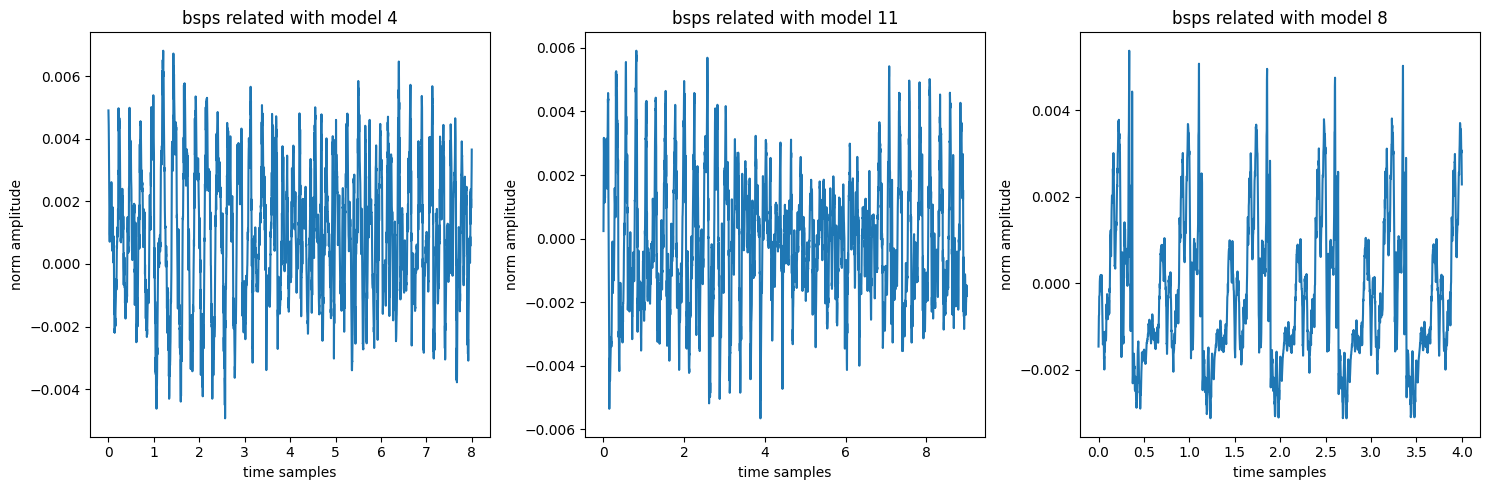

In [15]:
#plotting bsps

random_ind = random.sample(range(len(bsps_all_models)), 3)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(random_ind):

    t = np.arange(len(bsps_all_models[idx][0, :]))/500
    print(t.shape)
    axs[i].plot(t, bsps_all_models[idx][0, :]) 
    axs[i].set_title(f'bsps related with model {idx}')  
    axs[i].set_xlabel('time samples')
    axs[i].set_ylabel('norm amplitude')

plt.tight_layout()
plt.show()

In [16]:
#nos quedamos con 64 nodos para los bsps como chaqueta
bsps_64_all_models = []
for i in range(len(bsps_all_models)):

    bsps_64 = bsps_all_models[i][A[1].ravel(),:]
    print(bsps_64.shape)
    bsps_64_all_models.append(bsps_64)


(64, 1500)
(64, 2499)
(64, 1301)
(64, 1500)
(64, 4000)
(64, 4000)
(64, 2000)
(64, 2000)
(64, 2001)
(64, 2499)
(64, 2499)
(64, 4501)


In [17]:
print(len(bsps_64_all_models))
print(bsps_64_all_models[0][0,:].shape)
bsps_ex_signal = bsps_64_all_models[0][0,:].reshape(1,-1)
print(bsps_ex_signal.shape)
bsps_ex_signal[0].shape

12
(1500,)
(1, 1500)


(1500,)

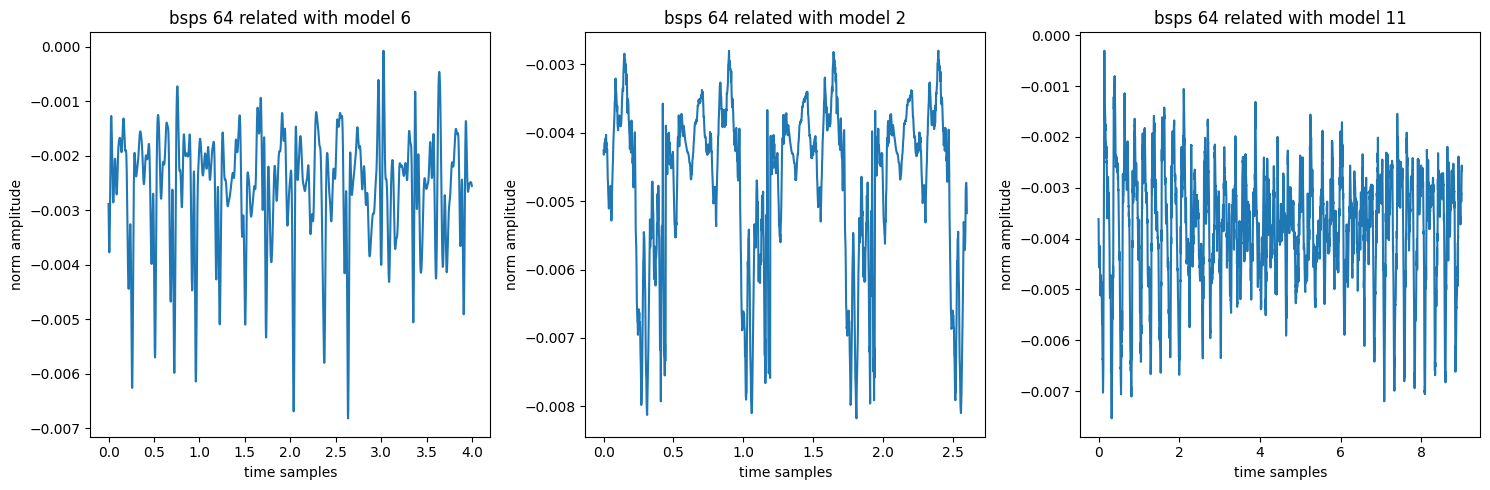

In [18]:
#plotting bsps

random_ind = random.sample(range(len(bsps_64_all_models)), 3)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(random_ind):

    t = np.arange(len(bsps_64_all_models[idx][0, :]))/500
    axs[i].plot(t, bsps_64_all_models[idx][0, :]) 
    axs[i].set_title(f'bsps 64 related with model {idx}')  
    axs[i].set_xlabel('time samples')
    axs[i].set_ylabel('norm amplitude')

plt.tight_layout()
plt.show()

SACO SPECTROGRAM DE FOURIER

In [19]:
print(len(bsps_64_all_models))

print(bsps_64_all_models[0][0,:].shape)  # primer nodo (de 64) del primer modelo (de 12)

bsps_ex_signal_all_models = []
for i in range(len(bsps_64_all_models)):

    bsps_ex_signal = bsps_64_all_models[i][0,:].reshape(1,-1)  # si pongo [1,:] me quedo con el segundo nodo y asi sucesivamente
    print(bsps_ex_signal.shape)
    bsps_ex_signal[0].shape
    bsps_ex_signal_all_models.append(bsps_ex_signal)

12
(1500,)
(1, 1500)
(1, 2499)
(1, 1301)
(1, 1500)
(1, 4000)
(1, 4000)
(1, 2000)
(1, 2000)
(1, 2001)
(1, 2499)
(1, 2499)
(1, 4501)


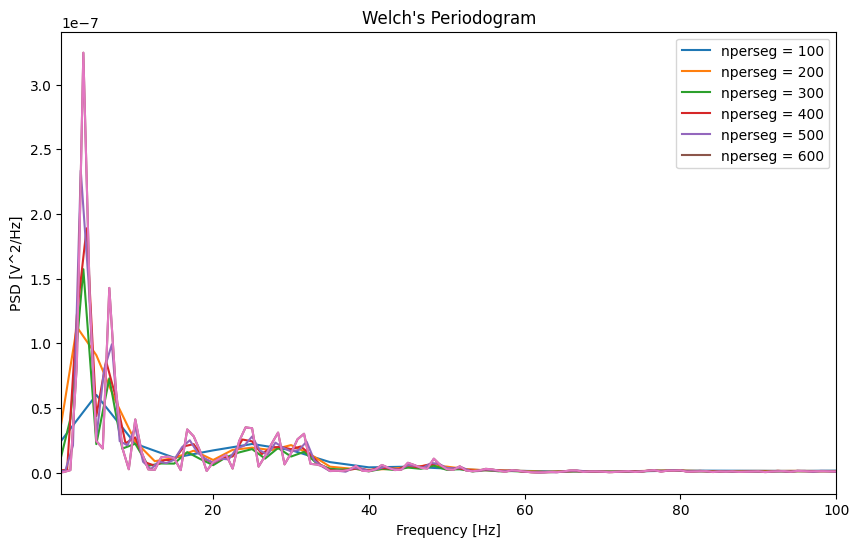

In [29]:
#ploteamos para un nodo y un solo modelo el periodograma de welch con diferentes nperseg para encontrar cual nos da mejor resultado

from scipy.signal import welch
plt.figure(figsize=(10, 6))

nperseg = [100, 200, 300, 400, 500, 600]

for i in range(len(nperseg)):
    freq, psd = welch(bsps_ex_signal_all_models[0][0], fs=500, nperseg=nperseg[i], noverlap=nperseg[i] // 2)
    #plt.figure(figsize=(10, 6))
    plt.plot(freq, psd, label=f'nperseg = {nperseg[i]}')   # --> vemos que sale mejor con nperseg = 600


plt.plot(freq, psd)
plt.title("Welch's Periodogram")
plt.xlabel("Frequency [Hz]")
plt.xlim(0.5, 100)  # --> acotamos el eje x para ver mejor porque cardiac signal estan en un rango menor que 100 hz
plt.ylabel("PSD [V^2/Hz]")
plt.legend()
plt.show()

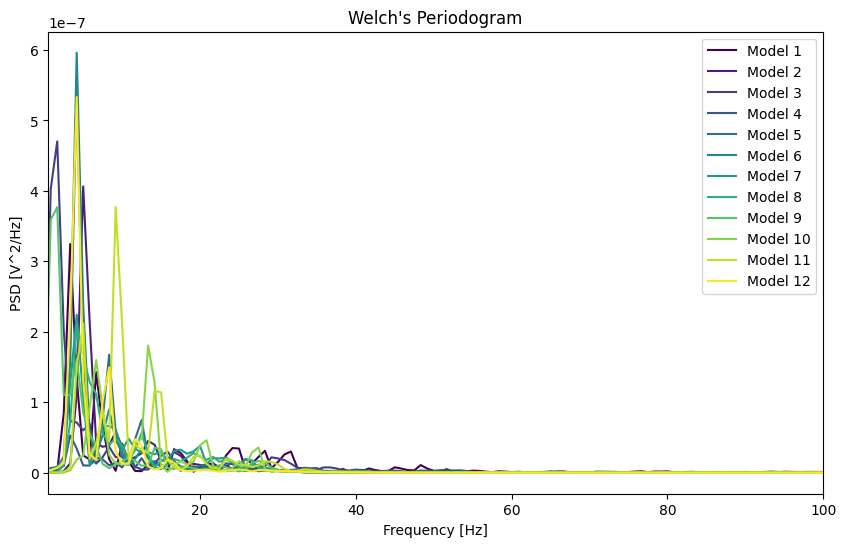

In [30]:


plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(bsps_ex_signal_all_models)))  # Generar una lista de colores

nperseg=600
for i in range(len(bsps_ex_signal_all_models)):

    freq, psd = welch(bsps_ex_signal_all_models[i][0], fs=500, nperseg=nperseg, noverlap=nperseg // 2)

    plt.plot(freq, psd, label=f'Model {i+1}', color=colors[i])

plt.title("Welch's Periodogram")
plt.xlabel("Frequency [Hz]")
plt.xlim(0.5, 100) 
plt.ylabel("PSD [V^2/Hz]")
plt.legend()  
   
plt.show()


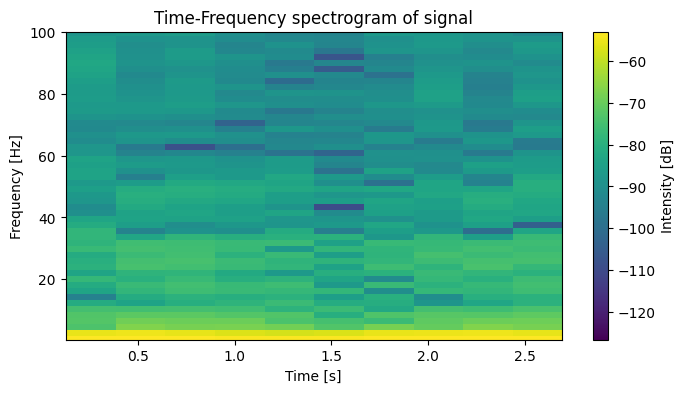

In [22]:
#aqui estoy haciendo el spectrogram para un solo nodo y un solo modelo

# como vemos en el periodograma anterior, la intensidad mas alta se obtiene en esas frecuencias en el rango 0-10 hz aprox
# linea amarilla mucho mas intensa que las demas que se mantiene en el tiempo porque la señal es periodica

#como es periódica tenemos los mismos componentes frecuenciales en toda la longitud temporal de la señal
#los 5 Hz (lo que sale amarillo) es una componente frecuencial constante, que es el ritmo al que salen los latidos má o menos

plt.figure(figsize=(8, 4))
plt.specgram(bsps_64_all_models[0][0,:], Fs=500)
plt.title("Time-Frequency spectrogram of signal")
plt.xlabel("Time [s]")
plt.ylim(0.5, 100)
plt.ylabel("Frequency [Hz]")
plt.colorbar(label='Intensity [dB]')
plt.show()

12
(4000,)


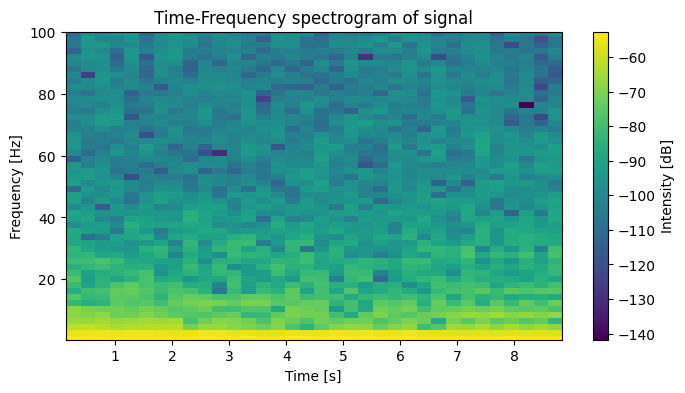

In [23]:
#sprecrograma para todos los modelos para un solo nodo


print(len(bsps_ex_signal_all_models))
print(bsps_ex_signal_all_models[4][0,:].shape)

plt.figure(figsize=(8,4))
for i in range(len(bsps_ex_signal_all_models)):
    plt.specgram(bsps_64_all_models[i][0,:], Fs=500)
plt.title("Time-Frequency spectrogram of signal")
plt.xlabel("Time [s]")
plt.ylim(0.5, 100)
plt.ylabel("Frequency [Hz]")
plt.colorbar(label='Intensity [dB]')
plt.show()

Uso un bsps_64 rel con el modelo 0 para aplicarle wavelet scattering, sacar los coefficientes de diferente orden (0, 1 o 2) y dibujar esos coefficientes dependiendo de su orden. 

Que uso tienen y que representan los coeffs de distinto orden: 

* 0: Coeficiente de orden cero (energía total de la señal).
* 1: Coeficiente de primer orden (captura variaciones locales).
* 2: Coeficiente de segundo orden (captura interacciones entre diferentes escalas).

In [24]:
from kymatio import Scattering1D

signal_ex = bsps_64_all_models[0][0, :]
T = len(signal_ex)

scattering = Scattering1D(J=6, shape=T, Q=8) #calculate wavelet scattering coeffs

# Perform the scattering transform
Sx = scattering(signal_ex)
meta = scattering.meta()

# Metadata
print("meta keys", meta.keys())  

# Explorar los órdenes de los coeficientes
print('order of coeffs', meta['order'])  # coeff order

order_0_coeffs = Sx[meta['order'] == 0]  # coeffs order 0
print("Coeffs order 0:", order_0_coeffs.shape)

order_1_coeffs = Sx[meta['order'] == 1] # coeffs order 1
print("Coeffs order 1:", order_1_coeffs.shape)

order_2_coeffs = Sx[meta['order'] == 2] # coeffs order 2
print("Coeffs order 2:", order_2_coeffs.shape)

#------------------------------------------------------------------------------------------------------
#no entiendo bien que es 23 en los tamaños de los coeficientes


meta keys dict_keys(['order', 'xi', 'sigma', 'j', 'n', 'key'])
order of coeffs [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Coeffs order 0: (1, 23)
Coeffs order 1: (38, 23)
Coeffs order 2: (87, 23)


#### 
#### **INFO DE LOS KEYS QUE SALEN EN LA METADATA:**

* order: Indica el orden del coeficiente de dispersión. Puede ser 0, 1 o 2, donde:
- 0: Coeficiente de orden cero (energía total de la señal).
- 1: Coeficiente de primer orden (captura variaciones locales).
- 2: Coeficiente de segundo orden (captura interacciones entre diferentes escalas).

* xi: Frecuencia central del filtro wavelet utilizado para calcular el coeficiente. Representa la frecuencia a la que el filtro wavelet es más sensible.

* sigma: Ancho del filtro wavelet en el dominio de la frecuencia. Indica la selectividad en frecuencia del filtro.

* j: Escala del filtro wavelet. Representa la dilatación del filtro wavelet y está relacionada con la resolución temporal y frecuencial.

* n: Índice del filtro wavelet dentro de una escala específica. Se utiliza para diferenciar entre diferentes filtros dentro de la misma escala.

* key: Clave única que identifica el coeficiente de dispersión. Puede ser utilizada para acceder a los coeficientes específicos en el conjunto de resultados.

23
only 1 coeff of order 0


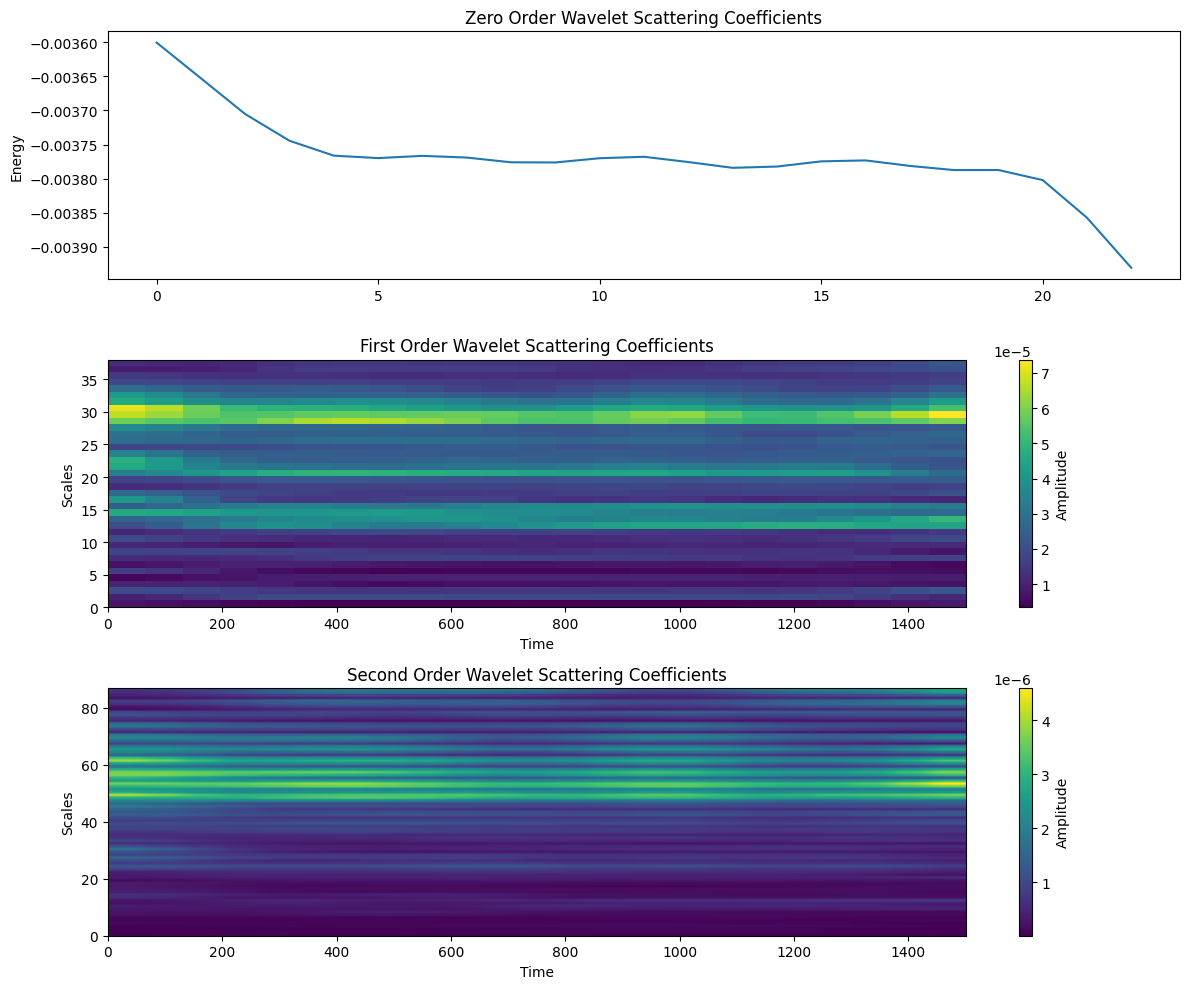

In [26]:
# PLOTTING SCATTERING COEFFS DEPENDING ON THE ORDER

plt.figure(figsize=(12, 10))

# Coeffs order 0
plt.subplot(3, 1, 1)
print(len(order_0_coeffs[0]))
#plt.plot(order_0_coeffs.T)

if len(order_0_coeffs) > 1:
    print("more than 1 coeff", len(order_0_coeffs))
    plt.plot(order_0_coeffs[0])
    

else:
    print("only 1 coeff of order 0")
    plt.plot(order_0_coeffs[0])

plt.title('Zero Order Wavelet Scattering Coefficients')
plt.ylabel('Energy')


# Coeffs order 1
plt.subplot(3, 1, 2)
plt.imshow(order_1_coeffs, aspect='auto', cmap='viridis', extent=[0, len(signal_ex), 0, order_1_coeffs.shape[0]])
plt.colorbar(label='Amplitude')
plt.title('First Order Wavelet Scattering Coefficients')
plt.xlabel('Time')
plt.ylabel('Scales')

# Coeffs order 2
plt.subplot(3, 1, 3)
plt.imshow(order_2_coeffs, aspect='auto', cmap='viridis', extent=[0, len(signal_ex), 0, order_2_coeffs.shape[0]])
plt.colorbar(label='Amplitude')
plt.title('Second Order Wavelet Scattering Coefficients')
plt.xlabel('Time')
plt.ylabel('Scales')

plt.tight_layout()
plt.show()

(126, 23)


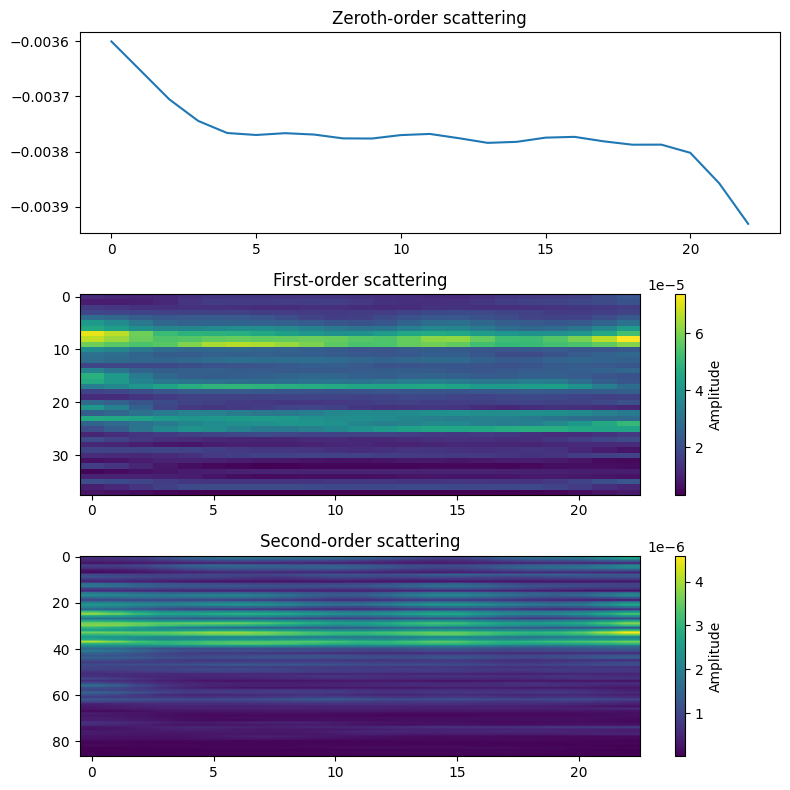

(126, 39)


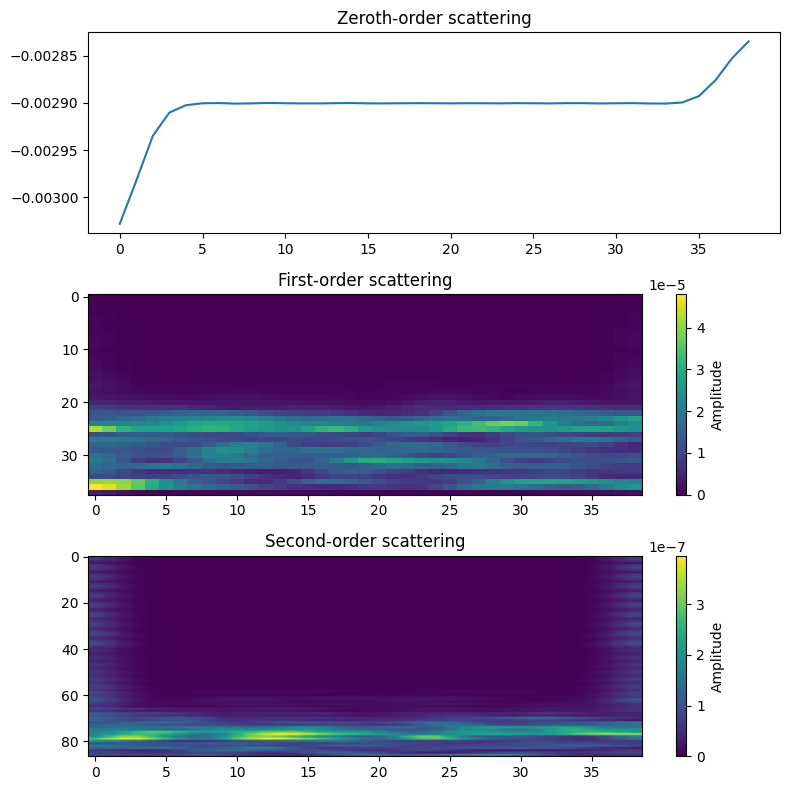

(126, 21)


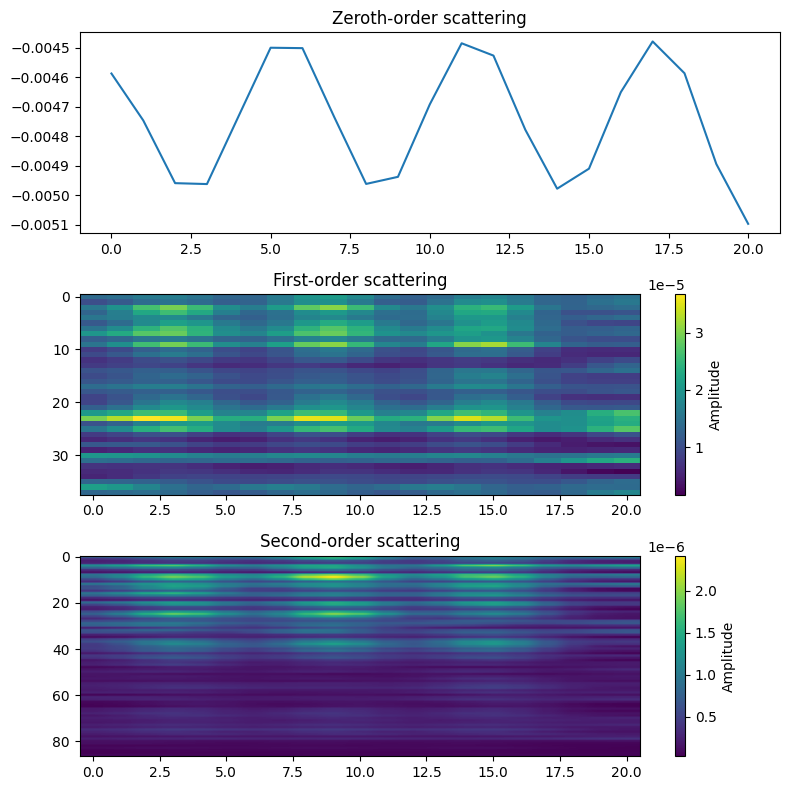

(126, 23)


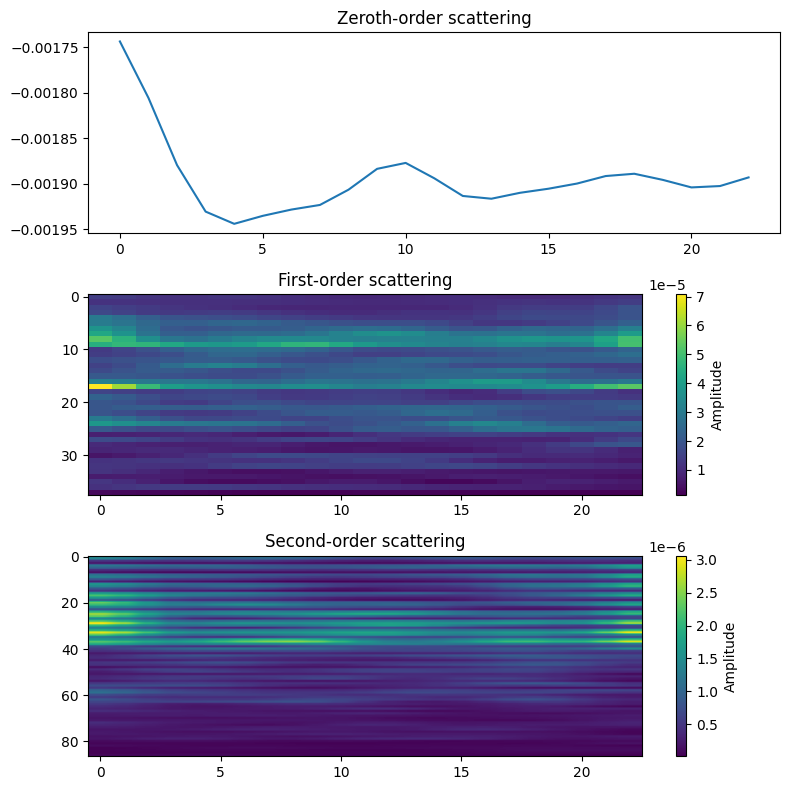

(126, 63)


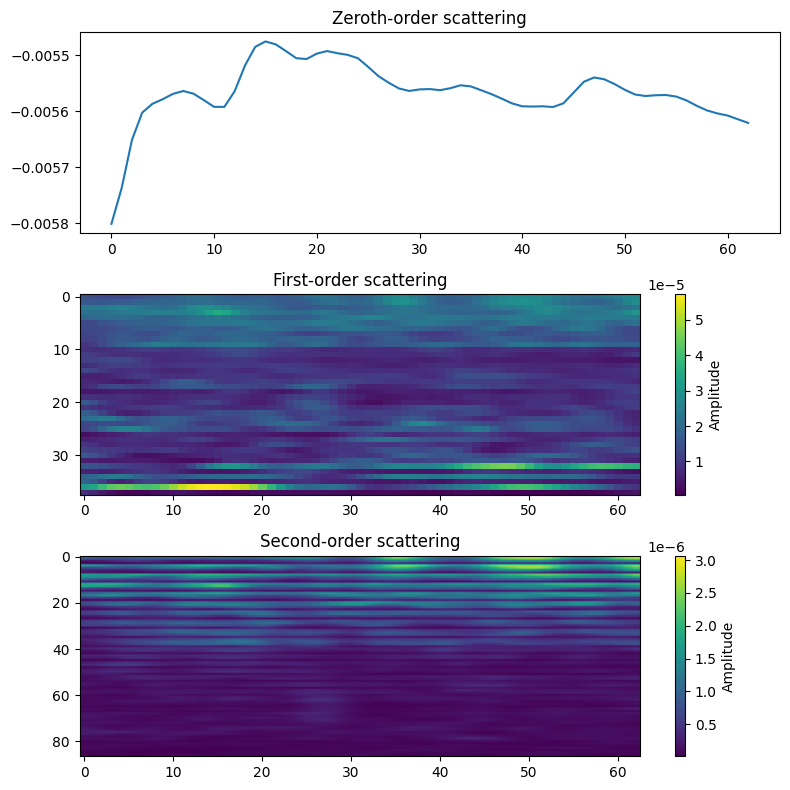

(126, 63)


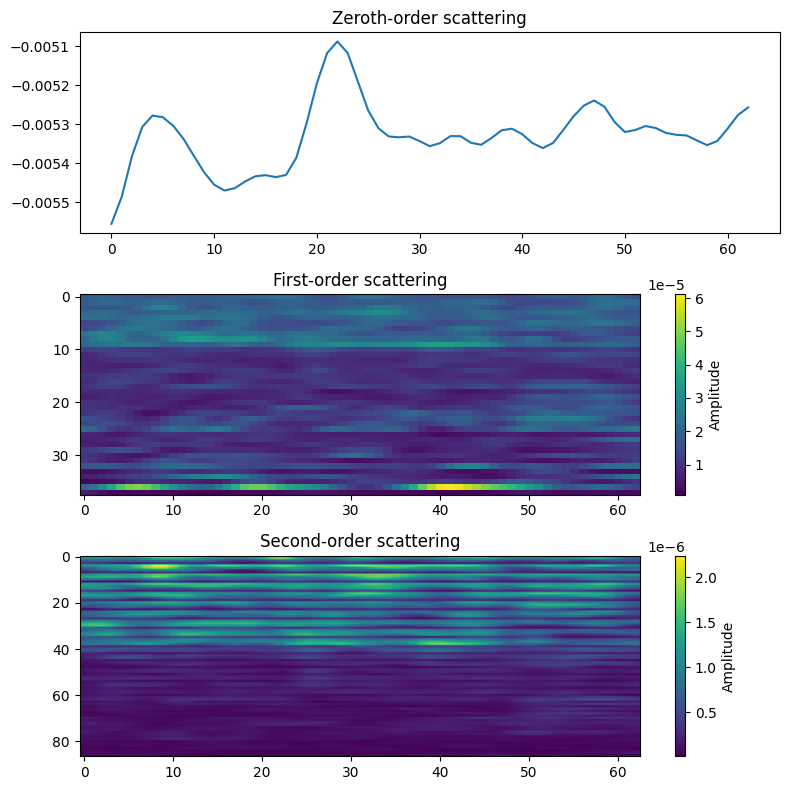

(126, 31)


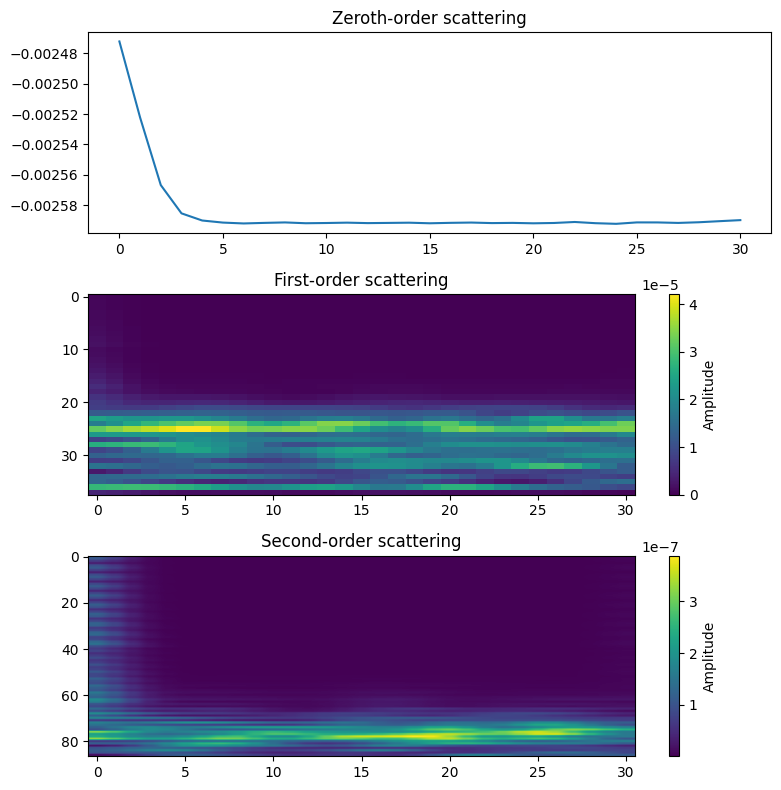

(126, 31)


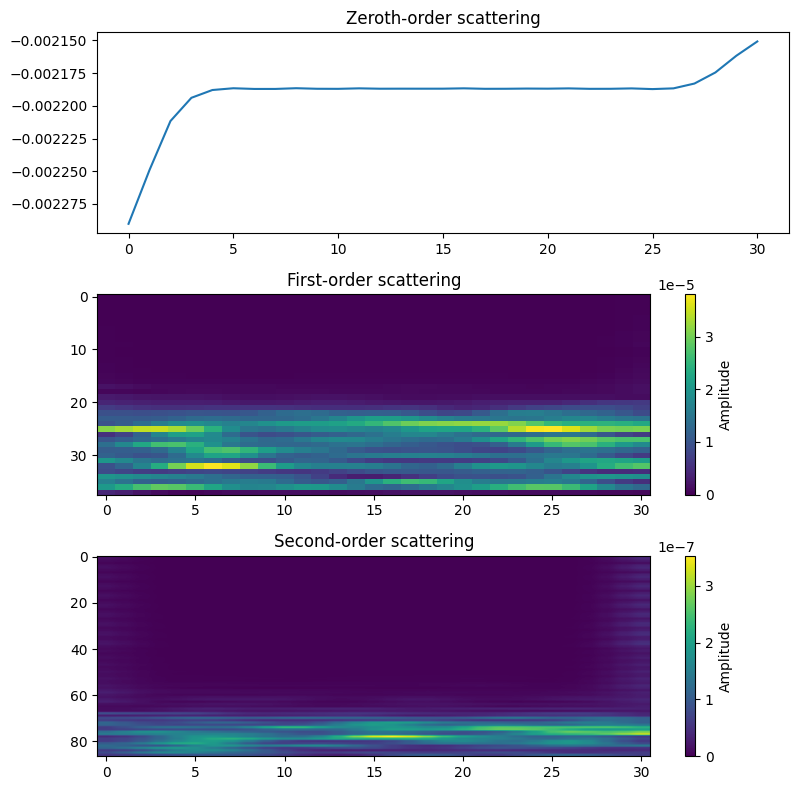

(126, 31)


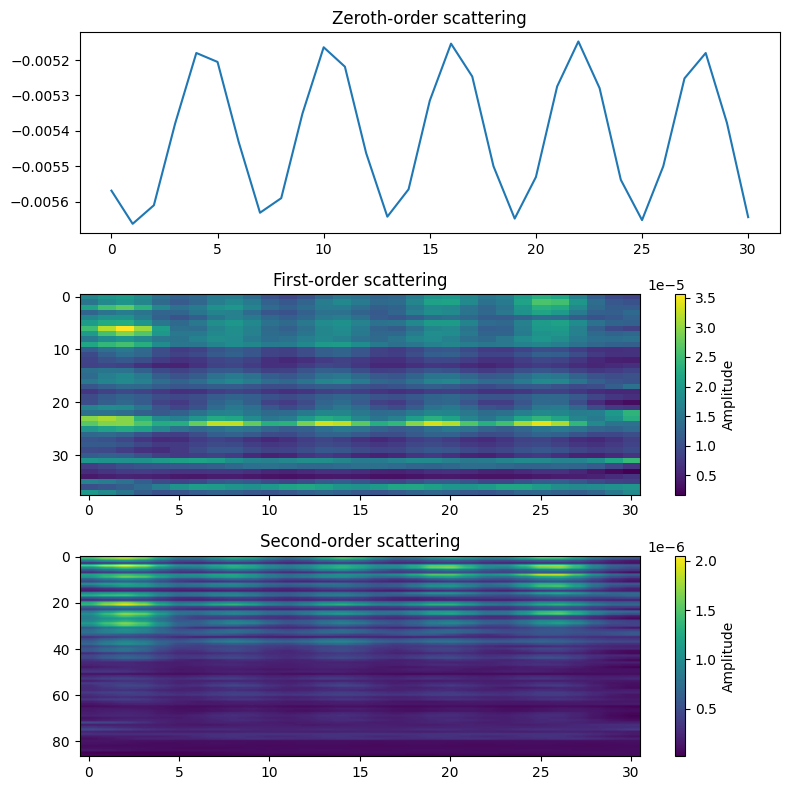

(126, 39)


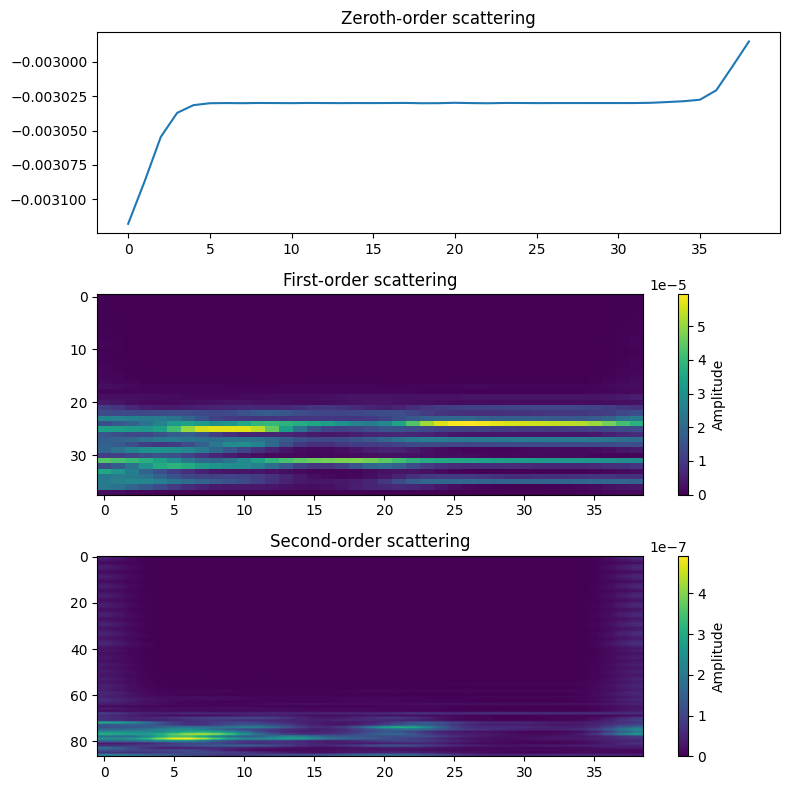

(126, 39)


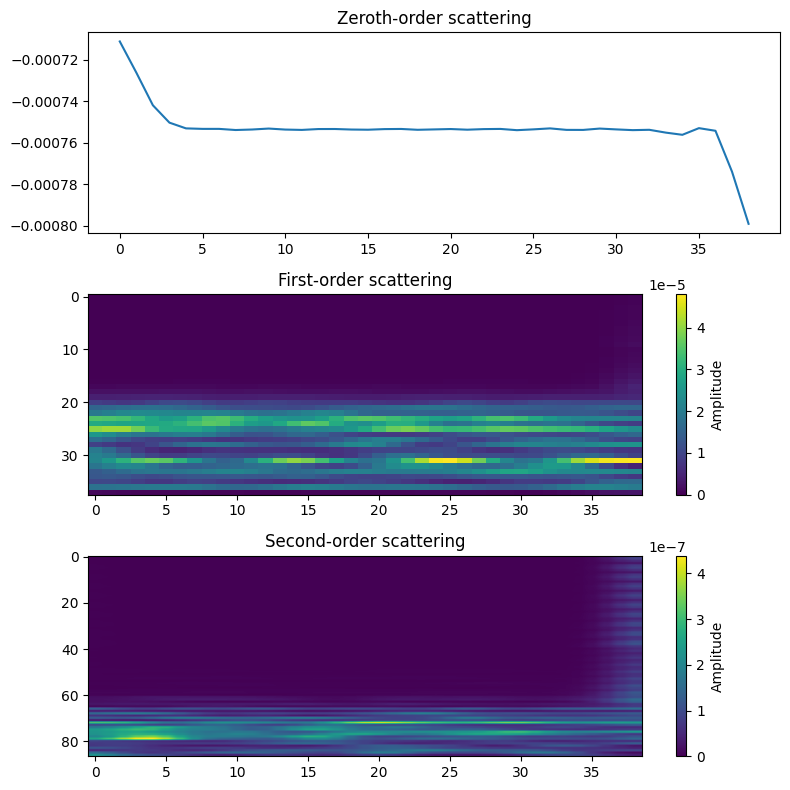

(126, 71)


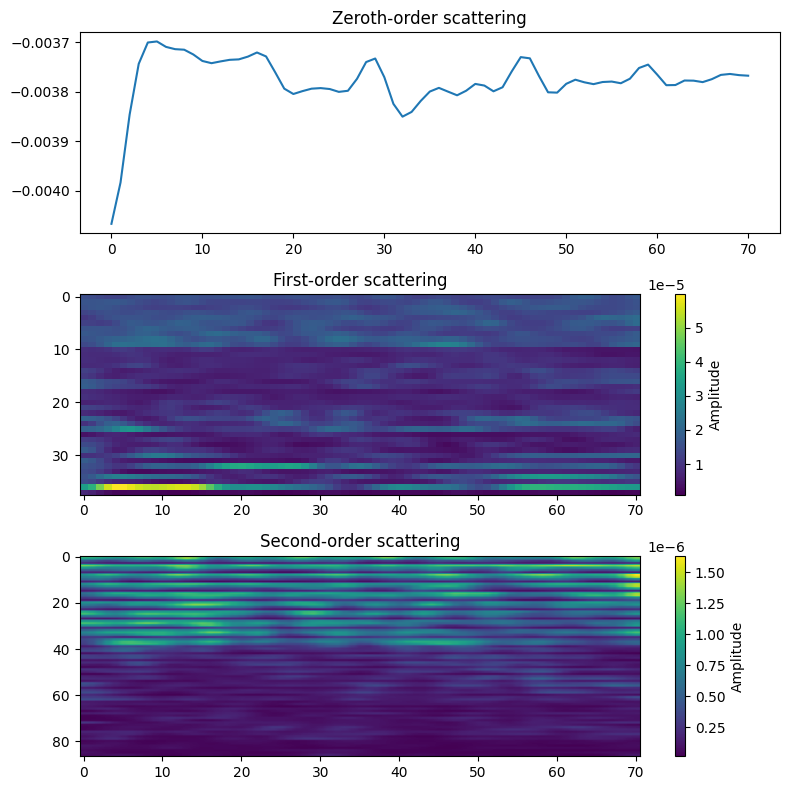

In [31]:
ws_coeffs_all_models = []
ws_coeffs_order0 = []
ws_coeffs_order1 = []
ws_coeffs_order2 = []


for i in range(len(bsps_64_all_models)):

    signal = bsps_64_all_models[i][0, :]
    T = len(signal)
    scattering = Scattering1D(J=6, shape=T, Q=8) #calculate wavelet scattering coeffs

    # Perform the scattering transform
    Sx = scattering(signal)
    meta = scattering.meta()
    print(Sx.shape)
    ws_coeffs_all_models.append(Sx)

    #print('order of coeffs', meta['order'])  # coeff order

    order_0 = np.where(meta['order'] == 0)  # coeffs order 0
    #print("Coeffs order 0:", order_0.shape)
    ws_coeffs_order0.append(order_0)

    order_1 = np.where(meta['order'] == 1) # coeffs order 1
    #print("Coeffs order 1:", order_1.shape)
    ws_coeffs_order1.append(order_1)

    order_2 = np.where(meta['order'] == 2) # coeffs order 2
    #print("Coeffs order 2:", order_2.shape)
    ws_coeffs_order2.append(order_2)

    plt.figure(figsize=(8, 8))
    plt.subplot(3, 1, 1)
    plt.plot(Sx[order_0][0])
    plt.title('Zeroth-order scattering')

    plt.subplot(3, 1, 2)
    plt.imshow(Sx[order_1], aspect='auto')
    plt.title('First-order scattering')
    plt.colorbar(label='Amplitude')

    plt.subplot(3, 1, 3)
    plt.imshow(Sx[order_2], aspect='auto')
    plt.title('Second-order scattering')
    plt.colorbar(label='Amplitude')
    
    plt.tight_layout()

    plt.show()

In [43]:
plt.figure(figsize=(8, 8))
plt.subplot(3, 1, 1)
plt.plot(Sx[order0][0])
plt.title('Zeroth-order scattering')
plt.subplot(3, 1, 2)
plt.imshow(Sx[order1], aspect='auto')
plt.title('First-order scattering')
plt.subplot(3, 1, 3)
plt.imshow(Sx[order2], aspect='auto')
plt.title('Second-order scattering')
plt.tight_layout()
plt.show()



ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (12, 1) + inhomogeneous part.

In [21]:
# We need a small constant to add to the scattering coefficients before
# computing the logarithm. This prevents very large values when the scattering
# coefficients are very close to zero.
log_eps = 1e-6

# puede servir, web kymatio ex https://github.com/kymatio/kymatio/blob/main/examples/1d/classif_keras.py 

In [20]:
# To increase discriminability, we take the logarithm of the scattering
# coefficients (after adding a small constant to make sure nothing blows up
# when scattering coefficients are close to zero). This is known as the
# log-scattering transform.

#x = layers.Lambda(lambda x: tf.math.log(tf.abs(x) + log_eps))(x)

#https://www.kymat.io/gallery_1d/plot_synthetic.html 

NameError: name 'x' is not defined